In [1]:
import numpy as np 
import pandas as pd 

In [2]:
data = {
    "CGPA": [5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,9.5], 
    "IQ": [90,95,100,105,110,115,120,125,130,135], 
    "Salary": [3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5]
}

In [3]:
df = pd.DataFrame(data)

In [4]:
df.head(10)

,CGPA,IQ,Salary
0,5.0,90,3.0
1,5.5,95,3.5
2,6.0,100,4.0
3,6.5,105,4.5
4,7.0,110,5.0
5,7.5,115,5.5
6,8.0,120,6.0
7,8.5,125,6.5
8,9.0,130,7.0
9,9.5,135,7.5


In [5]:
X = df[["CGPA" , "IQ"]].values 
y = df["Salary"].values

In [6]:
print("X:")
print(X)

X:
[[  5.   90. ]
 [  5.5  95. ]
 [  6.  100. ]
 [  6.5 105. ]
 [  7.  110. ]
 [  7.5 115. ]
 [  8.  120. ]
 [  8.5 125. ]
 [  9.  130. ]
 [  9.5 135. ]]


In [7]:
print("y:")
print(y)

y:
[3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5]


## Feature Scaling 

In [8]:
X = df[["CGPA" , "IQ"]].values.astype(float)

In [9]:
X[: , 0] = X[: , 0] / 10 

In [10]:
X[: , 1] = X[: , 1] / 100

In [11]:
X

array([[0.5 , 0.9 ],
       [0.55, 0.95],
       [0.6 , 1.  ],
       [0.65, 1.05],
       [0.7 , 1.1 ],
       [0.75, 1.15],
       [0.8 , 1.2 ],
       [0.85, 1.25],
       [0.9 , 1.3 ],
       [0.95, 1.35]])

In [12]:
print(X)

[[0.5  0.9 ]
 [0.55 0.95]
 [0.6  1.  ]
 [0.65 1.05]
 [0.7  1.1 ]
 [0.75 1.15]
 [0.8  1.2 ]
 [0.85 1.25]
 [0.9  1.3 ]
 [0.95 1.35]]


In [13]:
print(y)

[3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5]


## Manual Prediction 

In [14]:
# let initially i have weights w1 = 0.5 , and w2 = 0.3
X_first = np.array([0.5,0.9])
w_first = np.array([0.5,0.3]) 

dot_product_first = np.dot(X_first,w_first)

print(dot_product_first)

0.52


In [15]:
# now add the bias and let it is
b_first=0.1 
y_pred_first_student = np.dot(X_first , w_first) + b_first 
print(y_pred_first_student)

0.62


In [16]:
# now do this whole prediction for all the 10 students at once 

w = np.array([0.5,0.3])
b = 0.1 

y_pred = np.dot(X,w) + b 

print(y_pred)

[0.62 0.66 0.7  0.74 0.78 0.82 0.86 0.9  0.94 0.98]


In [17]:
results = pd.DataFrame({
    "Actual Salary" : y,
    "Predicted Salary" : y_pred
})

results

,Actual Salary,Predicted Salary
0,3.0,0.62
1,3.5,0.66
2,4.0,0.70
3,4.5,0.74
4,5.0,0.78
5,5.5,0.82
6,6.0,0.86
7,6.5,0.90
8,7.0,0.94
9,7.5,0.98


In [18]:
# Errors 
errors = y - y_pred 
print(errors)

[2.38 2.84 3.3  3.76 4.22 4.68 5.14 5.6  6.06 6.52]


In [19]:
# squared error 
squared_error = errors ** 2 
print(squared_error)

[ 5.6644  8.0656 10.89   14.1376 17.8084 21.9024 26.4196 31.36   36.7236
 42.5104]


In [20]:
# calculate MSE 
mse = np.mean(squared_error) 
print(mse)

21.5482


In [21]:
# doing by manually
total_squared_error = np.sum(squared_error) 
print(total_squared_error)

215.482


In [22]:
mse_manual = total_squared_error / len(y) 
print(mse_manual)

21.5482


In [23]:
# Now make a function that will return MSE by taking weights and bias 

In [24]:
def calculate_mse(X,y,w,b): 
    y_prediction = np.dot(X,w) + b
    error = y - y_prediction 
    squared_errors = error ** 2 
    mse = np.mean(squared_errors) 
    return mse

In [25]:
w = np.array([0.5 , 0.3]) 
b = 0.1 

loss = calculate_mse(X,y,w,b) 

print(loss)

21.5482


In [26]:
# NOw calculate the loss on different parameters 

Iteration 1: w1=0.52, w2=0.31, b=0.11, Loss=21.2199
Iteration 2: w1=0.54, w2=0.32, b=0.12, Loss=20.8943
Iteration 3: w1=0.56, w2=0.33, b=0.13, Loss=20.5712
Iteration 4: w1=0.58, w2=0.34, b=0.14, Loss=20.2507
Iteration 5: w1=0.60, w2=0.35, b=0.15, Loss=19.9328
Iteration 6: w1=0.62, w2=0.36, b=0.16, Loss=19.6175
Iteration 7: w1=0.64, w2=0.37, b=0.17, Loss=19.3048
Iteration 8: w1=0.66, w2=0.38, b=0.18, Loss=18.9947
Iteration 9: w1=0.68, w2=0.39, b=0.19, Loss=18.6872
Iteration 10: w1=0.70, w2=0.40, b=0.20, Loss=18.3823
Iteration 11: w1=0.72, w2=0.41, b=0.21, Loss=18.0799
Iteration 12: w1=0.74, w2=0.42, b=0.22, Loss=17.7802
Iteration 13: w1=0.76, w2=0.43, b=0.23, Loss=17.4830
Iteration 14: w1=0.78, w2=0.44, b=0.24, Loss=17.1885
Iteration 15: w1=0.80, w2=0.45, b=0.25, Loss=16.8965
Iteration 16: w1=0.82, w2=0.46, b=0.26, Loss=16.6072
Iteration 17: w1=0.84, w2=0.47, b=0.27, Loss=16.3204
Iteration 18: w1=0.86, w2=0.48, b=0.28, Loss=16.0362
Iteration 19: w1=0.88, w2=0.49, b=0.29, Loss=15.7546
It

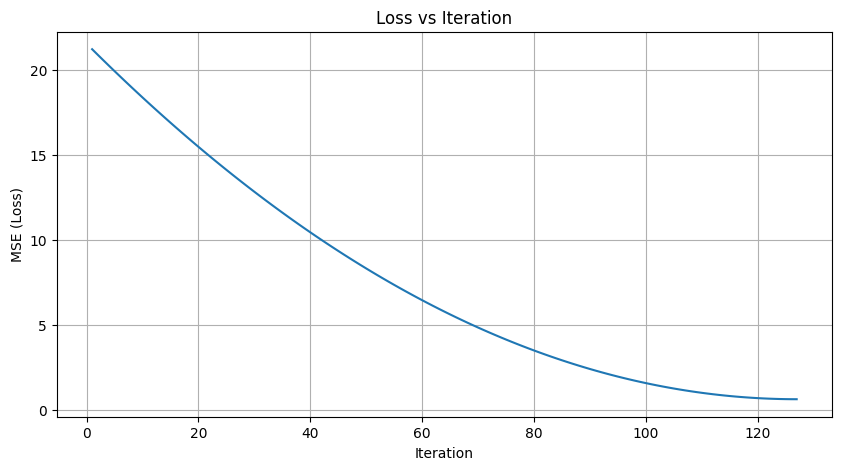

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Starting weights and bias
w = np.array([0.5, 0.3])
b = 0.1

# Store loss values
losses = []

# Try different parameter values
for i in range(127):

    # Gradually change weights and bias
    w[0] += 0.02
    w[1] += 0.01
    b += 0.01

    # Calculate loss
    loss = calculate_mse(X, y, w, b)

    # Store loss
    losses.append(loss)

    print(f"Iteration {i+1}: "
          f"w1={w[0]:.2f}, "
          f"w2={w[1]:.2f}, "
          f"b={b:.2f}, "
          f"Loss={loss:.4f}")


# Plot the loss graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, 128), losses)

plt.xlabel("Iteration")
plt.ylabel("MSE (Loss)")
plt.title("Loss vs Iteration")

plt.grid(True)
plt.show()

## Finding the gradient of bais b  and update it 

In [29]:
# --------------------------------
# 1. Starting values
# --------------------------------

initial_w = np.array([0.5, 0.3])
initial_b = 0.1

learning_rate = 0.01

In [30]:
# --------------------------------
# 2. Prediction
# --------------------------------

predicted_salary = np.dot(X, initial_w) + initial_b

print("Predicted Salary:")
print(predicted_salary)

Predicted Salary:
[0.62 0.66 0.7  0.74 0.78 0.82 0.86 0.9  0.94 0.98]


In [31]:
# --------------------------------
# 3. Error
# --------------------------------

prediction_error = y - predicted_salary

print("\nPrediction Error:")
print(prediction_error)


Prediction Error:
[2.38 2.84 3.3  3.76 4.22 4.68 5.14 5.6  6.06 6.52]


In [32]:
# --------------------------------
# 4. Derivative / Gradient of b
# --------------------------------

number_of_students = len(y)

bias_gradient = -(2 / number_of_students) * np.sum(prediction_error)

print("\nBias Gradient:")
print(bias_gradient)


Bias Gradient:
-8.9


In [33]:
# --------------------------------
#  Derivative / Gradient of b
# --------------------------------

number_of_students = len(y)

bias_gradient = -(2 / number_of_students) * np.sum(prediction_error)

print("\nBias Gradient:")
print(bias_gradient)



Bias Gradient:
-8.9


In [34]:
# --------------------------------
# 5. Update b
# --------------------------------

updated_b = initial_b - learning_rate * bias_gradient

print("\nOld b:")
print(initial_b)

print("\nNew b:")
print(updated_b)


Old b:
0.1

New b:
0.189


# Prediction → Error → Bias Gradient → New Bias

## Same finding the gradient of W1 and update it 

In [35]:
# --------------------------------
# 1. Starting values
# --------------------------------

starting_w1 = 0.5
starting_w2 = 0.3
starting_b = 0.1

learning_rate_w1 = 0.01

In [36]:
# --------------------------------
# 2. Prediction
# --------------------------------

salary_prediction_w1 = (
    starting_w1 * X[:, 0]
    + starting_w2 * X[:, 1]
    + starting_b
)

print("Predictions:")
print(salary_prediction_w1)


Predictions:
[0.62 0.66 0.7  0.74 0.78 0.82 0.86 0.9  0.94 0.98]


In [37]:
# --------------------------------
# 3. Error
# --------------------------------

error_for_w1 = y - salary_prediction_w1

print("\nErrors:")
print(error_for_w1)


Errors:
[2.38 2.84 3.3  3.76 4.22 4.68 5.14 5.6  6.06 6.52]


In [38]:
# --------------------------------
# 4. Error × x1
# --------------------------------

error_x1 = error_for_w1 * X[:, 0]

print("\nError × x1:")
print(error_x1)


Error × x1:
[1.19  1.562 1.98  2.444 2.954 3.51  4.112 4.76  5.454 6.194]


In [39]:
# --------------------------------
# 5. Sum of Error × x1
# --------------------------------

sum_error_x1 = np.sum(error_x1)

print("\nSum of Error × x1:")
print(sum_error_x1)


Sum of Error × x1:
34.16


In [40]:
# --------------------------------
# 6. Gradient of w1
# --------------------------------

students_w1 = len(y)

gradient_w1 = -(2 / students_w1) * sum_error_x1

print("\nGradient of w1:")
print(gradient_w1)



Gradient of w1:
-6.832


In [41]:
# --------------------------------
# 7. Update w1
# --------------------------------

updated_w1 = (
    starting_w1
    - learning_rate_w1 * gradient_w1
)

print("\nOld w1:")
print(starting_w1)

print("\nNew w1:")
print(updated_w1)


Old w1:
0.5

New w1:
0.56832


## Same finding the gradient of W2 and update it 

In [42]:
# --------------------------------
# 1. Starting values
# --------------------------------

starting_w1_w2 = 0.5
starting_w2_w2 = 0.3
starting_b_w2 = 0.1

learning_rate_w2 = 0.01

In [43]:
# --------------------------------
# 2. Prediction
# --------------------------------

salary_prediction_w2 = (
    starting_w1_w2 * X[:, 0]
    + starting_w2_w2 * X[:, 1]
    + starting_b_w2
)

print("Predictions:")
print(salary_prediction_w2)

Predictions:
[0.62 0.66 0.7  0.74 0.78 0.82 0.86 0.9  0.94 0.98]


In [44]:
# --------------------------------
# 3. Error
# --------------------------------

error_for_w2 = y - salary_prediction_w2

print("\nErrors:")
print(error_for_w2)



Errors:
[2.38 2.84 3.3  3.76 4.22 4.68 5.14 5.6  6.06 6.52]


In [45]:
# --------------------------------
# 4. Error × x2
# --------------------------------

error_x2 = error_for_w2 * X[:, 1]

print("\nError × x2:")
print(error_x2)



Error × x2:
[2.142 2.698 3.3   3.948 4.642 5.382 6.168 7.    7.878 8.802]


In [46]:
# --------------------------------
# 5. Sum of Error × x2
# --------------------------------

sum_error_x2 = np.sum(error_x2)

print("\nSum of Error × x2:")
print(sum_error_x2)



Sum of Error × x2:
51.96


In [47]:
# --------------------------------
# 6. Gradient of w2
# --------------------------------

students_w2 = len(y)

gradient_w2 = -(2 / students_w2) * sum_error_x2

print("\nGradient of w2:")
print(gradient_w2)


Gradient of w2:
-10.392000000000001


In [48]:
# --------------------------------
# 7. Update w2
# --------------------------------

updated_w2 = (
    starting_w2_w2
    - learning_rate_w2 * gradient_w2
)

print("\nOld w2:")
print(starting_w2_w2)

print("\nNew w2:")
print(updated_w2)


Old w2:
0.3

New w2:
0.40392
